# k-Nearest Neighbors — Glass Classification

This notebook builds a k-nearest neighbors classifier for the Glass Identification dataset.

Each row represents a glass sample, and the target is the type of glass.

## Goals

Walk through a complete classification workflow:

- Load the data
- Inspect class distribution
- Visualize feature relationships
- Split and scale the features
- Choose the best `k` using cross-validation
- Fit a final k-NN model
- Evaluate model performance

Evaluate the classifier using:

- Cross-validation accuracy
- Test accuracy
- Classification report
- Confusion matrix
- Decision boundary visualization using two features

Interpret how the choice of `k` affects model flexibility and performance.

## Dataset

- Source: Glass Identification dataset
- Size: 214 glass samples
- Features: 9 chemical composition measurements:
  - RI
  - Na
  - Mg
  - Al
  - Si
  - K
  - Ca
  - Ba
  - Fe

## Target

- The target is multiclass glass type:
  - `1` = building windows, float-processed
  - `2` = building windows, non-float-processed
  - `3` = vehicle windows, float-processed
  - `5` = containers
  - `6` = tableware
  - `7` = headlamps

Class `4` is not present in this version of the dataset.

 Source: [UCI](https://archive.ics.uci.edu/dataset/42/glass+identification).

In [2]:
import os
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

DATA_DIR = (
    os.path.join(os.path.dirname(os.getcwd()), "data")
    if os.path.basename(os.getcwd()) == "notebooks"
    else "data"
)

os.makedirs(DATA_DIR, exist_ok=True)


def download_if_needed(url, filename):
    """Download a CSV if it doesn't already exist locally."""
    path = os.path.join(DATA_DIR, filename)

    if not os.path.exists(path):
        print(f"Downloading {filename} from {url}")
        urllib.request.urlretrieve(url, path)

    return path


sns.set_style("whitegrid")
np.random.seed(42)

## 1. Load data

In [3]:
path = download_if_needed(
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/glass.csv",
    "glass.csv",
)

cols = ["RI", "Na", "Mg", "Al", "Si", "K", "Ca", "Ba", "Fe", "Type"]

df = pd.read_csv(path, header=None, names=cols)

print("Shape:", df.shape)
print("\nClass distribution:")
print(df["Type"].value_counts().sort_index())

df.head()

Shape: (214, 10)

Class distribution:
Type
1    70
2    76
3    17
5    13
6     9
7    29
Name: count, dtype: int64


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


The 6 glass types are:- **1**: building windows, float-processed- **2**: building windows, non-float- **3**: vehicle windows, float-processed- **5**: containers- **6**: tableware- **7**: headlamps(Class 4 was dropped from the original UCI release.)

## 2. Visual inspection

/Users/lucasosborn/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


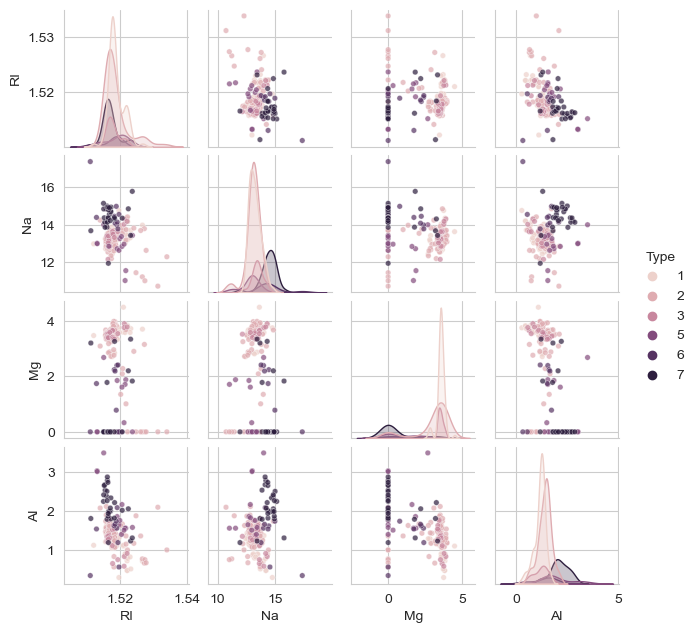

In [8]:
# Show pairwise relationships for a few key features
sns.pairplot(
    df[["RI", "Na", "Mg", "Al", "Type"]],
    hue="Type", height=1.6, plot_kws={"alpha": 0.7, "s": 16},
)
plt.show()

Some classes overlap heavily in feature space — this is a harder problem than typical toy datasets, which makes it a great test for k-NN.

## 3. Split + scale

In [4]:
X = df.drop(columns="Type").values
y = df["Type"].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()

X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

print(f"Train: {X_tr_s.shape}, Test: {X_te_s.shape}")

Train: (160, 9), Test: (54, 9)


## 4. Tune k via 5-fold cross-validation

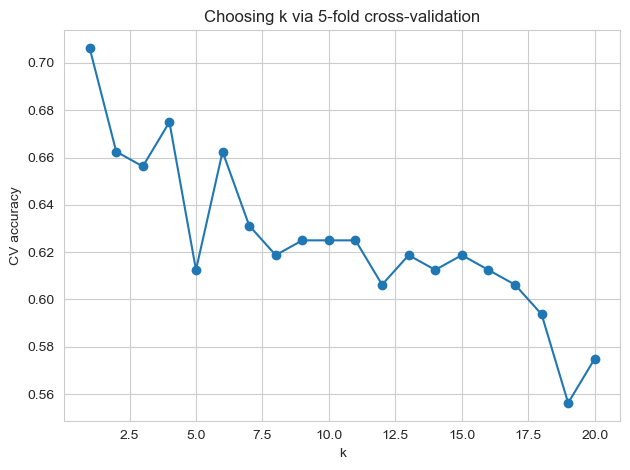

Best k: 1


In [5]:
ks = range(1, 21)

mean_scores = []

for k in ks:
    cv = cross_val_score(
        KNeighborsClassifier(n_neighbors=k),
        X_tr_s,
        y_tr,
        cv=5,
    )
    mean_scores.append(cv.mean())

plt.plot(list(ks), mean_scores, marker="o")
plt.xlabel("k")
plt.ylabel("CV accuracy")
plt.title("Choosing k via 5-fold cross-validation")

plt.tight_layout()
plt.show()

best_k = list(ks)[int(np.argmax(mean_scores))]

print(f"Best k: {best_k}")

## 5. Fit final model and evaluate

In [6]:
knn = KNeighborsClassifier(n_neighbors=best_k).fit(X_tr_s, y_tr)

preds = knn.predict(X_te_s)

print(f"Test accuracy: {accuracy_score(y_te, preds):.4f}\n")
print(classification_report(y_te, preds))

Test accuracy: 0.7407

              precision    recall  f1-score   support

           1       0.80      0.67      0.73        18
           2       0.70      0.74      0.72        19
           3       0.40      0.50      0.44         4
           5       0.75      1.00      0.86         3
           6       0.50      0.50      0.50         2
           7       1.00      1.00      1.00         8

    accuracy                           0.74        54
   macro avg       0.69      0.73      0.71        54
weighted avg       0.75      0.74      0.74        54



## 6. Confusion matrix

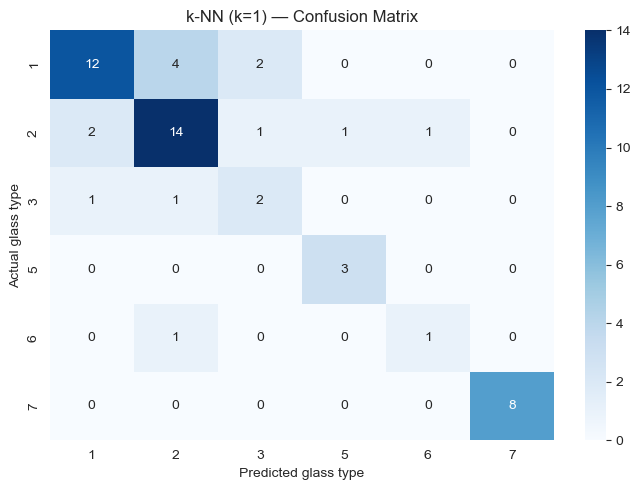

In [7]:
cm = confusion_matrix(y_te, preds, labels=knn.classes_)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=knn.classes_,
    yticklabels=knn.classes_,
)

plt.xlabel("Predicted glass type")
plt.ylabel("Actual glass type")
plt.title(f"k-NN (k={best_k}) — Confusion Matrix")
plt.tight_layout()
plt.show()

## 7. Decision boundary using two key features

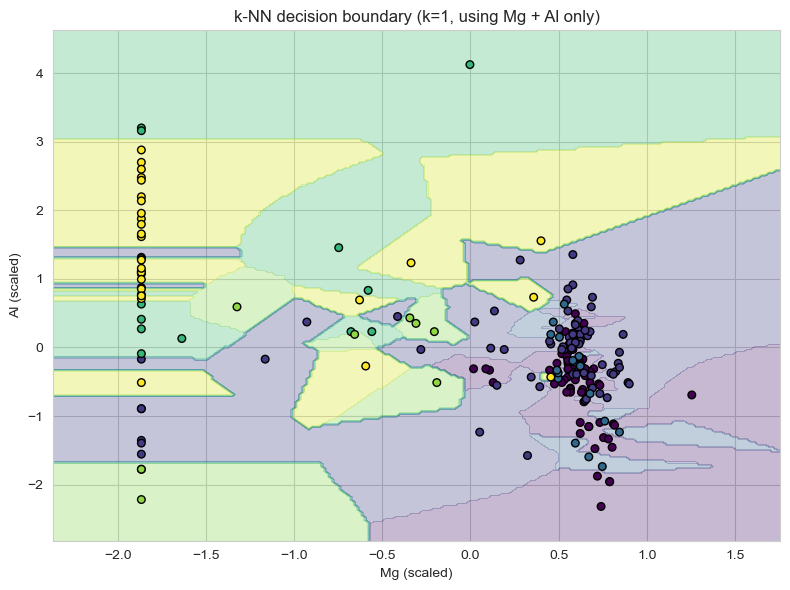

In [9]:
# Use Mg and Al — two of the most discriminative features
X2 = df[["Mg", "Al"]].values
sc2 = StandardScaler().fit(X2)
X2s = sc2.transform(X2)
knn2 = KNeighborsClassifier(n_neighbors=best_k).fit(X2s, y)
xx, yy = np.meshgrid(
    np.linspace(X2s[:, 0].min()-0.5, X2s[:, 0].max()+0.5, 200),
    np.linspace(X2s[:, 1].min()-0.5, X2s[:, 1].max()+0.5, 200),
)
Z = knn2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")
plt.scatter(X2s[:, 0], X2s[:, 1], c=y, edgecolor="k",
            cmap="viridis", s=30)
plt.xlabel("Mg (scaled)"); plt.ylabel("Al (scaled)")
plt.title(f"k-NN decision boundary (k={best_k}, using Mg + Al only)")
plt.tight_layout(); plt.show()

## Takeaways

- Glass classification is a harder real-world-style problem than the earlier toy-like datasets. The final test accuracy is 0.7407, meaning the model correctly classifies about 74% of the test set.

- The dataset is imbalanced. Classes 1 and 2 have the most samples, while classes 5 and 6 have very few, which makes those smaller classes harder for k-NN to learn reliably.

- Cross-validation selected `k = 1`, which gave the best validation accuracy. However, the decision boundary plot shows that `k = 1` creates very jagged regions, meaning the model is highly sensitive to individual training points.

- Scaling is essential for k-NN because it uses distance. Features like `RI`, `Si`, `Mg`, and `Al` are measured on very different scales, so standardizing prevents one feature from dominating the distance calculation.

- The confusion matrix shows strong performance on class 7, but more confusion between classes 1, 2, and 3. This matches the pairplot, where several glass types overlap heavily in feature space.